# 033 — Bistability Analysis (new_system dataset, R=50)

Full bistability analysis on `results/mas/final_dataset_new_system`.
35 tasks × 6 configs × 2 datasets = 420 cells, R=50 reps each.

Figures exported to `thesis/plots/bistab/`.


In [1]:
import sys
sys.path.insert(0, '..')

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

from src.metrics.bistability import analyse_bistability
from src.metrics.self_reinforcement import extract_runs

BASE   = Path('..') / 'results' / 'mas' / 'final_dataset_new_system'
EXPORT = Path('..') / 'thesis' / 'plots' / 'bistab'
EXPORT.mkdir(parents=True, exist_ok=True)

W_VALUES = [1, 2, 5]
TOPOS    = ['fc', 'star']
DATASETS = ['gpqa', 'hiddenbench']

from src.viz.thesis_style import (apply_style, W_COLORS, DS_COLORS, T_COLORS,
                                   DS_LABELS, T_LABELS, BISTAB_COLORS, CMAP_SEQ, no_grid)
LABEL_COLORS = {**BISTAB_COLORS, 'insufficient': '#aaaaaa'}

STRATA     = [('gpqa', 4), ('hiddenbench', 3), ('hiddenbench', 4)]
STRATA_LBL = {('gpqa',4):'GPQA (M=4)', ('hiddenbench',3):'HB (M=3)', ('hiddenbench',4):'HB (M=4)'}

apply_style()
print('setup ok')

/Users/I550854/Documents/Master Thesis/self-organization-mas/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


setup ok


In [2]:
# ── Load and run bistability analysis ────────────────────────────────────────
cell_rows  = []
comp_cache = {}

t0 = time.time()
for f in sorted(BASE.glob('**/*.json')):
    d    = json.loads(f.read_text())
    W    = d['W']
    ds   = d['dataset']
    topo = d.get('topology_name', 'fc')
    qid  = d['question_id']
    gt   = d['ground_truth']
    reps = d['repetitions']
    opts = tuple(d['options'].keys())

    r = analyse_bistability(reps, seed=42)

    dom_att   = max(r['p_hat'], key=r['p_hat'].get) if r['p_hat'] else None
    p_dom     = r['p_hat'].get(dom_att, float('nan'))
    dom_correct = (dom_att == gt) if dom_att is not None else float('nan')

    runs       = extract_runs(reps)
    slopes     = [x['slope'] for x in runs]
    mean_slope = float(np.mean(slopes)) if slopes else float('nan')
    p_sr       = float(np.mean(np.array(slopes) > 0)) if slopes else float('nan')

    accuracy = float(np.mean([rep['correct'] for rep in reps]))

    init_counts = {}
    for rep in reps:
        comp0 = tuple(rep['trajectory'][0]['phase_b'][i]['vote']
                      for i in range(len(rep['trajectory'][0]['phase_b'])))
        init_counts[comp0] = init_counts.get(comp0, 0) + 1
    d0 = 1.0 / sum((v/len(reps))**2 for v in init_counts.values())

    ci_lo, ci_hi = r['n_eff_ci']
    cell_rows.append({
        'dataset': ds, 'topology': topo, 'W': W, 'qid': qid, 'ground_truth': gt,
        'M': r['M'],
        'n_reps': r['n_reps'], 'n_converged': r['n_converged'],
        'n_settled': r['n_settled'], 'n_excluded': r['n_excluded'],
        'n_split': r['n_settled'] - r['n_converged'],
        'n_eff': r['n_eff'], 'n_eff_ci_lo': ci_lo, 'n_eff_ci_hi': ci_hi,
        'cramers_v': r['cramers_v'], 'p_basin': r['p_basin'],
        'label': r['label'], 'degree': r['degree'],
        'dom_attractor': str(dom_att), 'p_dominant': p_dom,
        'dom_correct': dom_correct,
        'mean_sr_slope': mean_slope, 'p_sr': p_sr,
        'accuracy': accuracy, 'd0': d0,
    })

    N_agents = reps[0]['N']
    counts = {}
    for rep in reps:
        for rd in rep['trajectory']:
            votes = [ag['vote'] for ag in rd['phase_b']]
            comp  = tuple(votes.count(o) for o in opts)
            counts[comp] = counts.get(comp, 0) + 1
    comp_cache[(ds, topo, W, qid)] = {
        'counts': counts, 'label': r['label'],
        'reps_detail': r['reps'], 'ground_truth': gt,
        'opts': opts, 'N': N_agents,
    }

elapsed = time.time() - t0
df = pd.DataFrame(cell_rows)
print(f'Done in {elapsed:.1f}s  |  cells: {len(df)}')
print()
print(df['label'].value_counts().to_string())
print()
print('M distribution:')
print(df.groupby(['dataset','M']).size().to_string())

Done in 27.7s  |  cells: 510

label
multistable    225
stochastic     181
monostable     104

M distribution:
dataset      M
gpqa         4    300
hiddenbench  3    186
             4     24


In [3]:
# ── Accounting funnel ─────────────────────────────────────────────────────────
print('=== CONVERGENCE ACCOUNTING ===')
tot = df['n_reps'].sum()
print(f'Total repetitions      : {tot:,}')
print(f'Settled (k>=3)         : {df["n_settled"].sum():,}  ({100*df["n_settled"].sum()/tot:.2f}%)')
print(f'  -> unanimous (kept)  : {df["n_converged"].sum():,}  ({100*df["n_converged"].sum()/tot:.2f}%)')
print(f'  -> split (excluded)  : {df["n_split"].sum():,}  ({100*df["n_split"].sum()/tot:.2f}%)')
print(f'Never settled (excl.)  : {(df["n_reps"]-df["n_settled"]).sum():,}'
      f'  ({100*(df["n_reps"]-df["n_settled"]).sum()/tot:.2f}%)')
print(f'Cells with n_c<2       : {(df["n_converged"]<2).sum()}')
print()
tab = df.groupby(['dataset','label']).size().unstack(fill_value=0)
for col in ['monostable','multistable','stochastic','insufficient']:
    if col not in tab.columns: tab[col] = 0
print(tab[['monostable','multistable','stochastic','insufficient']].to_string())
print()
grp = df.groupby(['dataset','topology','W','label']).size().unstack(fill_value=0).reset_index()
for col in ['monostable','multistable','stochastic','insufficient']:
    if col not in grp.columns: grp[col] = 0
print(grp[['dataset','topology','W','monostable','multistable','stochastic']].to_string(index=False))

=== CONVERGENCE ACCOUNTING ===
Total repetitions      : 25,500
Settled (k>=3)         : 25,190  (98.78%)
  -> unanimous (kept)  : 24,731  (96.98%)
  -> split (excluded)  : 459  (1.80%)
Never settled (excl.)  : 310  (1.22%)
Cells with n_c<2       : 0

label        monostable  multistable  stochastic  insufficient
dataset                                                       
gpqa                 86          151          63             0
hiddenbench          18           74         118             0

    dataset topology  W  monostable  multistable  stochastic
       gpqa       fc  1          13           31           6
       gpqa       fc  2          14           24          12
       gpqa       fc  5          14           27           9
       gpqa     star  1          15           26           9
       gpqa     star  2          14           22          14
       gpqa     star  5          16           21          13
hiddenbench       fc  1           4            9          22
hiddenbe

---
## Part 1 — N_eff / V distributions + label breakdown

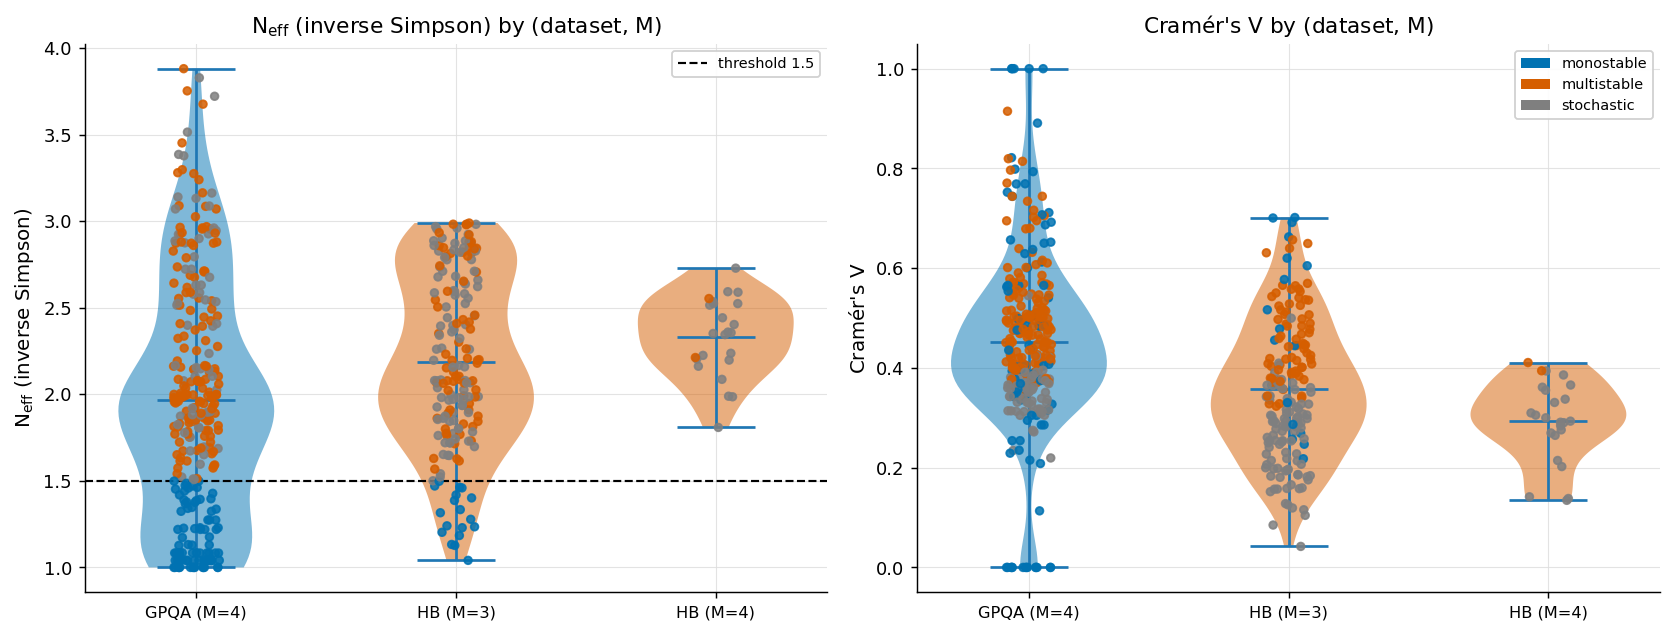

fig1 saved

=== Summary statistics within fixed M ===
GPQA (M=4)      n=300
  n_eff      : mean=1.965  median=1.901  max=3.882
  cramers_v  : mean=0.451  median=0.436  max=1.000

HB (M=3)        n=186
  n_eff      : mean=2.185  median=2.117  max=2.990
  cramers_v  : mean=0.357  median=0.344  max=0.702

HB (M=4)        n=24
  n_eff      : mean=2.331  median=2.354  max=2.729
  cramers_v  : mean=0.294  median=0.297  max=0.411



In [4]:
# Fig 1 — N_eff and V violin, stratified by M
from matplotlib.patches import Patch

valid = df[df['label'] != 'insufficient'].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, ylabel in zip(axes,
        ['n_eff', 'cramers_v'],
        ['$N_{\\mathrm{eff}}$ (inverse Simpson)', "Cramér's $V$"]):
    data = [valid[(valid['dataset']==ds)&(valid['M']==m)][col].dropna().values
            for ds,m in STRATA]
    positions = list(range(1, len(STRATA)+1))
    parts = ax.violinplot(data, positions=positions, widths=0.6,
                          showmeans=True, showmedians=False)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(DS_COLORS[STRATA[i][0]]); pc.set_alpha(0.5)
    for i, (ds, m) in enumerate(STRATA):
        s = valid[(valid['dataset']==ds)&(valid['M']==m)]
        vals = s[col].dropna()
        jitter = np.random.default_rng(42).uniform(-0.09, 0.09, len(vals))
        c = [LABEL_COLORS.get(lbl, '#aaaaaa') for lbl in s['label']]
        ax.scatter(np.array(positions[i]) + jitter, vals.values,
                   s=18, c=c, alpha=0.85, zorder=3)
    if col == 'n_eff':
        ax.axhline(1.5, color='black', linestyle='--', lw=1.2, label='threshold 1.5')
        ax.legend(fontsize=8)
    ax.set_xticks(positions)
    ax.set_xticklabels([STRATA_LBL[s] for s in STRATA], fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} by (dataset, M)')

handles = [Patch(facecolor=LABEL_COLORS[l], label=l)
           for l in ['monostable','multistable','stochastic']]
axes[1].legend(handles=handles, fontsize=8)
plt.tight_layout()
fig.savefig(EXPORT / 'fig1_neff_v_violin.png')
plt.show()
print('fig1 saved')

print()
print('=== Summary statistics within fixed M ===')
for ds, m in STRATA:
    sub = valid[(valid['dataset']==ds)&(valid['M']==m)]
    print(f'{STRATA_LBL[(ds,m)]:14s}  n={len(sub)}')
    for col in ['n_eff','cramers_v']:
        s = sub[col].dropna()
        print(f'  {col:11s}: mean={s.mean():.3f}  median={s.median():.3f}  max={s.max():.3f}')
    print()

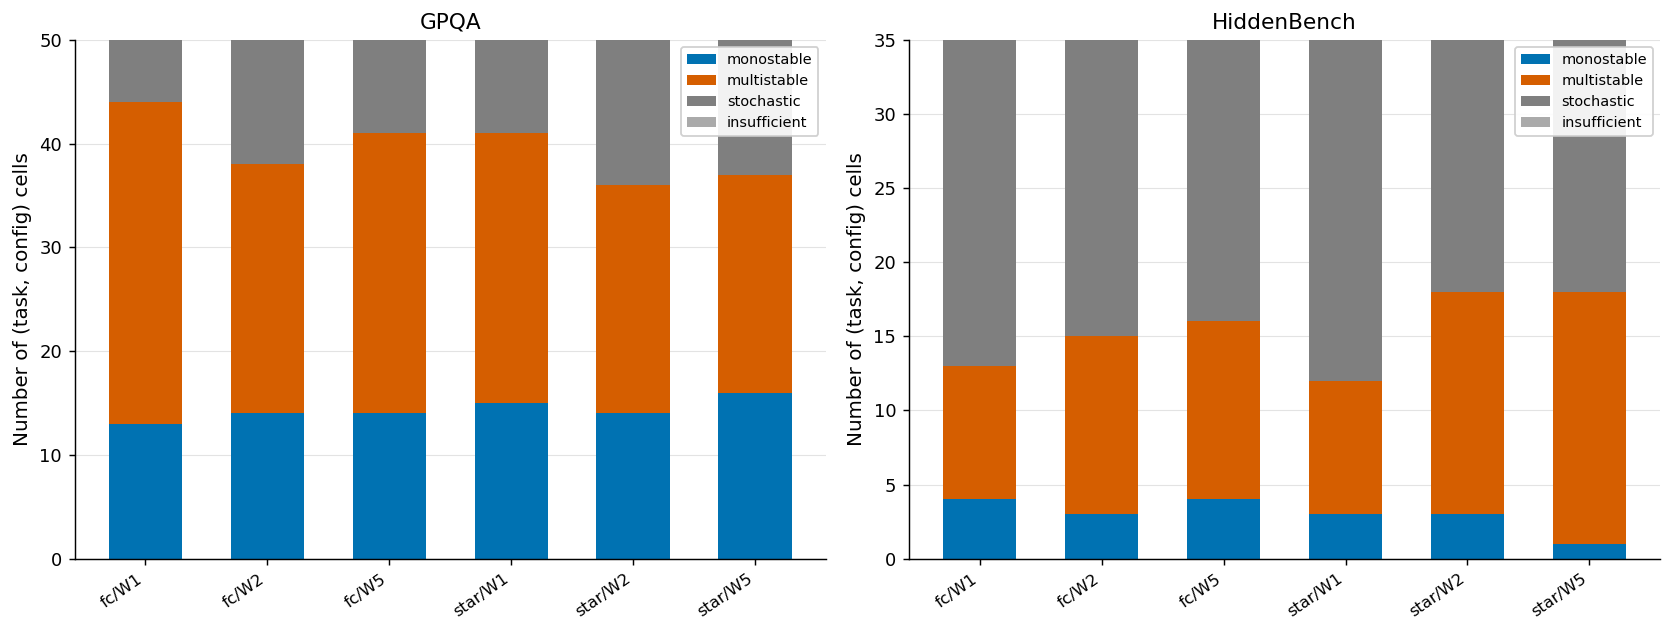

fig2 saved


In [5]:
# Label stacked bar by (dataset, config)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, ds in zip(axes, DATASETS):
    sub = df[df['dataset']==ds]
    configs = [f'{t}/W{w}' for t in TOPOS for w in W_VALUES]
    bottoms = np.zeros(len(configs))
    label_order = ['monostable','multistable','stochastic','insufficient']
    for lbl in label_order:
        heights = []
        for topo in TOPOS:
            for w in W_VALUES:
                s = sub[(sub['topology']==topo)&(sub['W']==w)]
                heights.append((s['label']==lbl).sum())
        ax.bar(range(len(configs)), heights, bottom=bottoms,
               color=LABEL_COLORS[lbl], label=lbl, width=0.6)
        bottoms += np.array(heights)
    ax.set_xticks(range(len(configs)))
    ax.set_xticklabels(configs, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Number of (task, config) cells')
    ax.set_title(DS_LABELS[ds])
    ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
fig.savefig(EXPORT / 'fig2_label_bars.png')
plt.show()
print('fig2 saved')

---
## Part 2 — Dominant attractor correctness

In [6]:
print('=== Dominant attractor == correct option ===')
valid2 = df[(df['label']!='insufficient')&(df['n_converged']>=2)].copy()
valid2['dom_correct_bool'] = valid2['dom_correct'].apply(
    lambda x: bool(x) if x == x else None)

for ds in DATASETS:
    sub = valid2[valid2['dataset']==ds].dropna(subset=['dom_correct_bool'])
    frac = sub['dom_correct_bool'].mean()
    print(f'  {DS_LABELS[ds]:12s}: {frac:.3f}  ({int(sub["dom_correct_bool"].sum())}/{len(sub)})')
print()
for lbl in ['monostable','multistable','stochastic']:
    sub = valid2[valid2['label']==lbl].dropna(subset=['dom_correct_bool'])
    if len(sub)==0: continue
    frac = sub['dom_correct_bool'].mean()
    print(f'  {lbl:14s}: {frac:.3f}  ({int(sub["dom_correct_bool"].sum())}/{len(sub)})')
print()

# GPQA: does dom-correct fraction differ by label?
for ds in DATASETS:
    print(f'{DS_LABELS[ds]}:')
    for lbl in ['monostable','multistable','stochastic']:
        sub = valid2[(valid2['dataset']==ds)&(valid2['label']==lbl)].dropna(subset=['dom_correct_bool'])
        if len(sub)<2: continue
        frac = sub['dom_correct_bool'].mean()
        print(f'  {lbl:14s}: {frac:.3f}  n={len(sub)}')
    print()

=== Dominant attractor == correct option ===
  GPQA        : 0.487  (146/300)
  HiddenBench : 0.238  (50/210)

  monostable    : 0.462  (48/104)
  multistable   : 0.449  (101/225)
  stochastic    : 0.260  (47/181)

GPQA:
  monostable    : 0.488  n=86
  multistable   : 0.483  n=151
  stochastic    : 0.492  n=63

HiddenBench:
  monostable    : 0.333  n=18
  multistable   : 0.378  n=74
  stochastic    : 0.136  n=118



---
## Part 3 — Configuration effects (topology, W)

In [7]:
valid = df[df['label'] != 'insufficient'].copy()

print('=== Topology comparison (fc vs star): N_eff and V ===')
for ds in DATASETS:
    print(DS_LABELS[ds])
    for w in W_VALUES:
        for col in ['n_eff','cramers_v']:
            fc   = valid[(valid['dataset']==ds)&(valid['topology']=='fc')  &(valid['W']==w)][col].dropna()
            star = valid[(valid['dataset']==ds)&(valid['topology']=='star')&(valid['W']==w)][col].dropna()
            if len(fc)<2 or len(star)<2: continue
            stat, p = sp_stats.mannwhitneyu(fc, star, alternative='two-sided')
            print(f'  W={w} {col:11s}: fc={fc.mean():.3f}  star={star.mean():.3f}  p={p:.4f}')
    print()

print('=== W effect (Kruskal-Wallis, per dataset x topo) ===')
for ds in DATASETS:
    for topo in TOPOS:
        for col in ['n_eff','cramers_v']:
            groups = [valid[(valid['dataset']==ds)&(valid['topology']==topo)&(valid['W']==w)][col].dropna().values
                      for w in W_VALUES]
            if any(len(g)<2 for g in groups): continue
            stat, p = sp_stats.kruskal(*groups)
            print(f'  {DS_LABELS[ds]:12s} {topo:5s} {col:11s}: H={stat:.3f}  p={p:.4f}')

print()
print('=== Multistable fraction per config ===')
print(f'  {"stratum":16s} {"topo":5s} ' + ' '.join(f'W={w:<6d}' for w in W_VALUES))
for ds, m in STRATA:
    for topo in TOPOS:
        row = []
        for w in W_VALUES:
            s = valid[(valid['dataset']==ds)&(valid['M']==m)&(valid['topology']==topo)&(valid['W']==w)]
            frac = (s['label']=='multistable').mean() if len(s) else float('nan')
            row.append(f'{frac:.2f}({len(s)})')
        print(f'  {STRATA_LBL[(ds,m)]:16s} {topo:5s} ' + ' '.join(f'{r:<8s}' for r in row))

=== Topology comparison (fc vs star): N_eff and V ===
GPQA
  W=1 n_eff      : fc=1.960  star=1.934  p=0.7986
  W=1 cramers_v  : fc=0.503  star=0.454  p=0.1777
  W=2 n_eff      : fc=1.992  star=1.989  p=0.8713
  W=2 cramers_v  : fc=0.454  star=0.409  p=0.1722
  W=5 n_eff      : fc=1.962  star=1.955  p=0.9615
  W=5 cramers_v  : fc=0.450  star=0.436  p=0.4080

HiddenBench
  W=1 n_eff      : fc=2.160  star=2.203  p=0.6810
  W=1 cramers_v  : fc=0.350  star=0.329  p=0.7422
  W=2 n_eff      : fc=2.242  star=2.189  p=0.5182
  W=2 cramers_v  : fc=0.338  star=0.363  p=0.4810
  W=5 n_eff      : fc=2.175  star=2.242  p=0.6983
  W=5 cramers_v  : fc=0.353  star=0.368  p=0.5809

=== W effect (Kruskal-Wallis, per dataset x topo) ===
  GPQA         fc    n_eff      : H=0.026  p=0.9873
  GPQA         fc    cramers_v  : H=1.405  p=0.4955
  GPQA         star  n_eff      : H=0.072  p=0.9648
  GPQA         star  cramers_v  : H=1.377  p=0.5023
  HiddenBench  fc    n_eff      : H=0.631  p=0.7295
  HiddenBench

---
## Part 4 — Accuracy

In [8]:
valid = df[df['label'] != 'insufficient'].copy()

print('=== Spearman: N_eff / V vs accuracy ===')
for ds in DATASETS:
    sub = valid[valid['dataset']==ds].dropna(subset=['n_eff','cramers_v','accuracy'])
    r1, p1 = sp_stats.spearmanr(sub['n_eff'],     sub['accuracy'])
    r2, p2 = sp_stats.spearmanr(sub['cramers_v'], sub['accuracy'])
    print(f'  {DS_LABELS[ds]:12s}  N_eff vs acc: rho={r1:.3f}  p={p1:.4f}'
          f'  |  V vs acc: rho={r2:.3f}  p={p2:.4f}  (n={len(sub)})')
print()

print('=== Mean accuracy by label ===')
for ds in DATASETS:
    print(DS_LABELS[ds])
    for lbl in ['monostable','multistable','stochastic']:
        sub = df[(df['label']==lbl)&(df['dataset']==ds)]['accuracy'].dropna()
        if len(sub)==0: continue
        print(f'  {lbl:14s}: mean={sub.mean():.3f}  median={sub.median():.3f}  n={len(sub)}')
    mono_acc = df[(df['label']=='monostable')&(df['dataset']==ds)]['accuracy'].dropna()
    mult_acc = df[(df['label']=='multistable')&(df['dataset']==ds)]['accuracy'].dropna()
    stoc_acc = df[(df['label']=='stochastic') &(df['dataset']==ds)]['accuracy'].dropna()
    for a_v, b_lbl, b_v in [(mono_acc,'vs multi',mult_acc),(mono_acc,'vs stoch',stoc_acc),(mult_acc,'vs stoch',stoc_acc)]:
        if len(a_v)<2 or len(b_v)<2: continue
        stat, p = sp_stats.mannwhitneyu(a_v, b_v, alternative='two-sided')
        print(f'    {b_lbl}: p={p:.4f}')
    print()

=== Spearman: N_eff / V vs accuracy ===
  GPQA          N_eff vs acc: rho=-0.152  p=0.0085  |  V vs acc: rho=0.048  p=0.4056  (n=300)
  HiddenBench   N_eff vs acc: rho=0.153  p=0.0265  |  V vs acc: rho=0.274  p=0.0001  (n=210)

=== Mean accuracy by label ===
GPQA
  monostable    : mean=0.467  median=0.200  n=86
  multistable   : mean=0.406  median=0.420  n=151
  stochastic    : mean=0.400  median=0.440  n=63
    vs multi: p=0.6417
    vs stoch: p=0.7699
    vs stoch: p=0.8491

HiddenBench
  monostable    : mean=0.361  median=0.160  n=18
  multistable   : mean=0.338  median=0.310  n=74
  stochastic    : mean=0.256  median=0.220  n=118
    vs multi: p=0.3469
    vs stoch: p=0.6503
    vs stoch: p=0.0027



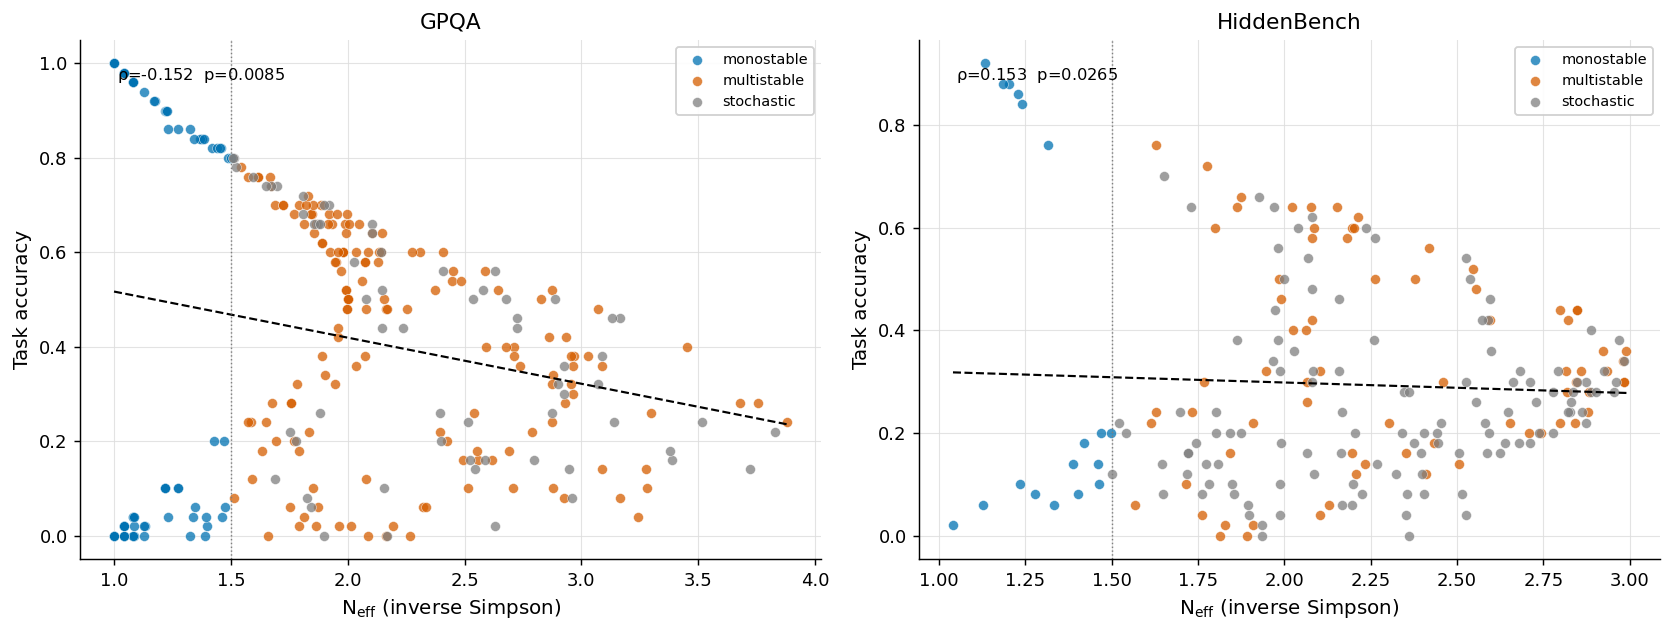

fig3 saved


In [9]:
# Fig 3 — N_eff vs accuracy scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
valid = df[df['label'] != 'insufficient'].copy()
for ax, ds in zip(axes, DATASETS):
    sub = valid[valid['dataset']==ds].dropna(subset=['n_eff','accuracy'])
    for lbl in ['monostable','multistable','stochastic']:
        s = sub[sub['label']==lbl]
        ax.scatter(s['n_eff'], s['accuracy'],
                   color=LABEL_COLORS[lbl], s=30, alpha=0.75,
                   label=lbl, edgecolors='white', linewidths=0.3)
    rho, p = sp_stats.spearmanr(sub['n_eff'], sub['accuracy'])
    m, b   = np.polyfit(sub['n_eff'], sub['accuracy'], 1)
    xs = np.linspace(sub['n_eff'].min(), sub['n_eff'].max(), 50)
    ax.plot(xs, m*xs+b, color='black', lw=1.2, linestyle='--')
    ax.text(0.05, 0.95, f'$\\rho$={rho:.3f}  p={p:.4f}',
            transform=ax.transAxes, fontsize=9, va='top')
    ax.axvline(1.5, color='grey', lw=0.8, linestyle=':')
    ax.set_xlabel('$N_{\\mathrm{eff}}$ (inverse Simpson)')
    ax.set_ylabel('Task accuracy')
    ax.set_title(DS_LABELS[ds])
    ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(EXPORT / 'fig3_neff_accuracy.png')
plt.show()
print('fig3 saved')

---
## Part 5 — Cross-motif: SR × Bistability

In [10]:
print('=== mean_sr_slope by label ===')
for lbl in ['monostable','multistable','stochastic']:
    sub = df[df['label']==lbl]['mean_sr_slope'].dropna()
    if len(sub)==0: continue
    print(f'  {lbl:14s}: mean={sub.mean():.3f}  median={sub.median():.3f}  n={len(sub)}')

mono_sr = df[df['label']=='monostable']['mean_sr_slope'].dropna()
stoc_sr = df[df['label']=='stochastic']['mean_sr_slope'].dropna()
mult_sr = df[df['label']=='multistable']['mean_sr_slope'].dropna()
print()
print('=== MWU: mean_sr_slope across labels ===')
for a_lbl, a_v, b_lbl, b_v in [
    ('monostable', mono_sr, 'stochastic', stoc_sr),
    ('monostable', mono_sr, 'multistable', mult_sr),
    ('stochastic', stoc_sr, 'multistable', mult_sr),
]:
    if len(a_v)<2 or len(b_v)<2: continue
    stat, p = sp_stats.mannwhitneyu(a_v, b_v, alternative='two-sided')
    print(f'  {a_lbl} vs {b_lbl}: p={p:.4f}  ({a_v.mean():.3f} vs {b_v.mean():.3f})')

print()
print('=== Spearman: N_eff vs mean_sr_slope (per dataset) ===')
valid = df[df['label']!='insufficient'].copy()
for ds in DATASETS:
    sub = valid[valid['dataset']==ds].dropna(subset=['n_eff','mean_sr_slope'])
    r, p = sp_stats.spearmanr(sub['n_eff'], sub['mean_sr_slope'])
    print(f'  {DS_LABELS[ds]:12s}: rho={r:.3f}  p={p:.4f}  n={len(sub)}')

=== mean_sr_slope by label ===
  monostable    : mean=0.560  median=0.568  n=104
  multistable   : mean=0.413  median=0.409  n=225
  stochastic    : mean=0.371  median=0.368  n=181

=== MWU: mean_sr_slope across labels ===
  monostable vs stochastic: p=0.0000  (0.560 vs 0.371)
  monostable vs multistable: p=0.0000  (0.560 vs 0.413)
  stochastic vs multistable: p=0.0000  (0.371 vs 0.413)

=== Spearman: N_eff vs mean_sr_slope (per dataset) ===
  GPQA        : rho=-0.656  p=0.0000  n=300
  HiddenBench : rho=-0.195  p=0.0045  n=210


---
## Part 6 — Initial diversity D0 as confounder check

In [11]:
valid = df[df['label']!='insufficient'].copy()

print('=== Spearman: D0 vs N_eff (per dataset) ===')
for ds in DATASETS:
    sub = valid[valid['dataset']==ds].dropna(subset=['d0','n_eff'])
    r, p = sp_stats.spearmanr(sub['d0'], sub['n_eff'])
    print(f'  {DS_LABELS[ds]:12s}: rho={r:.3f}  p={p:.4f}  n={len(sub)}')
print()

print('=== Partial Spearman: N_eff vs accuracy | D0 ===')
from scipy.stats import rankdata
for ds in DATASETS:
    sub = valid[valid['dataset']==ds].dropna(subset=['d0','n_eff','accuracy'])
    if len(sub)<5: continue
    rn = rankdata(sub['n_eff'].values).astype(float)
    rd = rankdata(sub['d0'].values).astype(float)
    ra = rankdata(sub['accuracy'].values).astype(float)
    slope, intercept = np.polyfit(rd, rn, 1)
    rn_res = rn - (slope*rd + intercept)
    slope2, intercept2 = np.polyfit(rd, ra, 1)
    ra_res = ra - (slope2*rd + intercept2)
    r_partial, p_partial = sp_stats.pearsonr(rn_res, ra_res)
    r_raw, p_raw = sp_stats.spearmanr(sub['n_eff'], sub['accuracy'])
    print(f'  {DS_LABELS[ds]:12s}: raw rho={r_raw:.3f} (p={p_raw:.4f})  '
          f'partial rho={r_partial:.3f} (p={p_partial:.4f})')

=== Spearman: D0 vs N_eff (per dataset) ===
  GPQA        : rho=0.826  p=0.0000  n=300
  HiddenBench : rho=-0.100  p=0.1492  n=210

=== Partial Spearman: N_eff vs accuracy | D0 ===
  GPQA        : raw rho=-0.152 (p=0.0085)  partial rho=-0.102 (p=0.0774)
  HiddenBench : raw rho=0.153 (p=0.0265)  partial rho=0.181 (p=0.0087)


---
## Part 7 — Task-level consistency across configs

In [12]:
print('=== Cross-config rank agreement of per-task N_eff ===')
for ds in DATASETS:
    sub = df[df['dataset']==ds].copy()
    sub['config'] = sub['topology'] + '_W' + sub['W'].astype(str)
    piv = sub.pivot_table(index='qid', columns='config', values='n_eff')
    configs = list(piv.columns)
    rhos = []
    for i in range(len(configs)):
        for j in range(i+1, len(configs)):
            a = piv[configs[i]]; b = piv[configs[j]]
            mask = a.notna() & b.notna()
            if mask.sum() < 5: continue
            rho, _ = sp_stats.spearmanr(a[mask], b[mask])
            rhos.append(rho)
    print(f'  {DS_LABELS[ds]:12s}: n_tasks={piv.shape[0]}  n_configs={len(configs)}  '
          f'pairwise Spearman mean={np.mean(rhos):.3f}  median={np.median(rhos):.3f}  '
          f'min={np.min(rhos):.3f}  max={np.max(rhos):.3f}')

print()
print('=== Task-level robustness: n_configs flagged multistable ===')
for ds in DATASETS:
    sub = df[df['dataset']==ds]
    n_multi_per_task = sub.assign(is_m=(sub['label']=='multistable')).groupby('qid')['is_m'].sum()
    dist = n_multi_per_task.value_counts().sort_index()
    print(f'  {DS_LABELS[ds]:12s}: ' + '  '.join(f'{int(k)}cfg:{int(v)}' for k,v in dist.items()))
    robust = (n_multi_per_task >= 4).sum()
    print(f'    tasks multistable in >=4 configs: {robust}')

=== Cross-config rank agreement of per-task N_eff ===
  GPQA        : n_tasks=50  n_configs=6  pairwise Spearman mean=0.902  median=0.906  min=0.835  max=0.945
  HiddenBench : n_tasks=35  n_configs=6  pairwise Spearman mean=0.782  median=0.796  min=0.597  max=0.880

=== Task-level robustness: n_configs flagged multistable ===
  GPQA        : 0cfg:12  1cfg:1  2cfg:4  3cfg:9  4cfg:13  5cfg:3  6cfg:8
    tasks multistable in >=4 configs: 24
  HiddenBench : 0cfg:10  1cfg:7  2cfg:5  3cfg:4  4cfg:4  5cfg:1  6cfg:4
    tasks multistable in >=4 configs: 9


---
## Part 8 — Original analysis: probing NEW vs OLD findings

In [13]:
# Does the anti-conformity prompt change bistability?
# We re-check the key patterns from the old notebook on the new data.

valid = df[df['label']!='insufficient'].copy()

print('=== SUMMARY TABLE ===')
lc = df['label'].value_counts()
for lbl in ['monostable','multistable','stochastic','insufficient']:
    n = lc.get(lbl,0)
    print(f'  {lbl:14s}: {n:3d} / {len(df)}  ({100*n/len(df):.1f}%)')
print()
print(f'N_eff overall: mean={valid["n_eff"].mean():.3f}  median={valid["n_eff"].median():.3f}')
print(f'N_eff > 1.5  : {(valid["n_eff"]>1.5).sum()} of {len(valid)} valid cells ({100*(valid["n_eff"]>1.5).mean():.1f}%)')
print(f'Cramers V overall mean: {valid["cramers_v"].mean():.3f}')
print()

for ds in DATASETS:
    sub = df[df['dataset']==ds]
    sub_v = sub[sub['label']!='insufficient']
    lc2 = sub['label'].value_counts()
    print(f'{DS_LABELS[ds]}')
    for lbl in ['monostable','multistable','stochastic']:
        print(f'  {lbl:14s}: {lc2.get(lbl,0)}  ({100*lc2.get(lbl,0)/len(sub):.1f}%)')
    for m in sorted(sub_v['M'].unique()):
        sm = sub_v[sub_v['M']==m]
        print(f'  N_eff mean (M={m}): {sm["n_eff"].mean():.3f}  (n={len(sm)})')
    dc = sub_v.dropna(subset=['dom_correct'])
    n_dc = int(dc['dom_correct'].sum())
    print(f'  Dom correct: {n_dc}/{len(dc)} ({100*n_dc/len(dc):.1f}%)')
    print()

=== SUMMARY TABLE ===
  monostable    : 104 / 510  (20.4%)
  multistable   : 225 / 510  (44.1%)
  stochastic    : 181 / 510  (35.5%)
  insufficient  :   0 / 510  (0.0%)

N_eff overall: mean=2.063  median=2.003
N_eff > 1.5  : 406 of 510 valid cells (79.6%)
Cramers V overall mean: 0.410

GPQA
  monostable    : 86  (28.7%)
  multistable   : 151  (50.3%)
  stochastic    : 63  (21.0%)
  N_eff mean (M=4): 1.965  (n=300)
  Dom correct: 146/300 (48.7%)

HiddenBench
  monostable    : 18  (8.6%)
  multistable   : 74  (35.2%)
  stochastic    : 118  (56.2%)
  N_eff mean (M=3): 2.185  (n=186)
  N_eff mean (M=4): 2.331  (n=24)
  Dom correct: 50/210 (23.8%)



In [14]:
# NOVEL ANALYSIS 1: Do GT-correct attractors have stronger basin selection (higher V)?
print('=== Cramers V: dom_correct vs not ===')
valid2 = valid.dropna(subset=['dom_correct'])
correct_v   = valid2[valid2['dom_correct']==True]['cramers_v'].dropna()
incorrect_v = valid2[valid2['dom_correct']==False]['cramers_v'].dropna()
stat, p = sp_stats.mannwhitneyu(correct_v, incorrect_v, alternative='two-sided')
print(f'  Dominant=correct: V={correct_v.mean():.3f}  n={len(correct_v)}')
print(f'  Dominant=wrong:   V={incorrect_v.mean():.3f}  n={len(incorrect_v)}')
print(f'  MWU p={p:.4f}')
print()
for ds in DATASETS:
    sub = valid2[valid2['dataset']==ds]
    cv  = sub[sub['dom_correct']==True]['cramers_v'].dropna()
    icv = sub[sub['dom_correct']==False]['cramers_v'].dropna()
    if len(cv)<2 or len(icv)<2: continue
    stat, p = sp_stats.mannwhitneyu(cv, icv, alternative='two-sided')
    print(f'  {DS_LABELS[ds]:12s}: correct_V={cv.mean():.3f}  wrong_V={icv.mean():.3f}  p={p:.4f}')

print()
# NOVEL ANALYSIS 2: N_eff vs convergence rate
print('=== N_eff vs convergence rate (n_converged / n_reps) ===')
df['conv_rate'] = df['n_converged'] / df['n_reps']
valid2 = df[df['label']!='insufficient'].copy()
for ds in DATASETS:
    sub = valid2[valid2['dataset']==ds].dropna(subset=['n_eff','conv_rate'])
    r, p = sp_stats.spearmanr(sub['n_eff'], sub['conv_rate'])
    print(f'  {DS_LABELS[ds]:12s}: rho={r:.3f}  p={p:.4f}  conv_rate mean={sub["conv_rate"].mean():.3f}')
print()

# NOVEL ANALYSIS 3: stochastic cells — are they high N_eff with weak basin selection?
print('=== Stochastic cells: N_eff and V distributions ===')
stoc = df[df['label']=='stochastic']
multi = df[df['label']=='multistable']
mono = df[df['label']=='monostable']
print(f'  stochastic   N_eff mean={stoc["n_eff"].mean():.3f}  V mean={stoc["cramers_v"].mean():.3f}  n={len(stoc)}')
print(f'  multistable  N_eff mean={multi["n_eff"].mean():.3f}  V mean={multi["cramers_v"].mean():.3f}  n={len(multi)}')
print(f'  monostable   N_eff mean={mono["n_eff"].mean():.3f}   V mean={mono["cramers_v"].mean():.3f}  n={len(mono)}')
# stochastic: high N_eff + V NOT significant
stoc_high_neff = stoc[stoc['n_eff']>=1.5]
print(f'  stochastic with N_eff>=1.5: {len(stoc_high_neff)} / {len(stoc)} ({100*len(stoc_high_neff)/len(stoc):.1f}%)')
print(f'    These have high N_eff but p_basin>=0.05 — coexistence without deterministic basin selection')

=== Cramers V: dom_correct vs not ===
  Dominant=correct: V=0.444  n=196
  Dominant=wrong:   V=0.388  n=314
  MWU p=0.0000

  GPQA        : correct_V=0.448  wrong_V=0.454  p=0.8240
  HiddenBench : correct_V=0.430  wrong_V=0.325  p=0.0000

=== N_eff vs convergence rate (n_converged / n_reps) ===
  GPQA        : rho=-0.218  p=0.0001  conv_rate mean=0.994
  HiddenBench : rho=-0.042  p=0.5472  conv_rate mean=0.935

=== Stochastic cells: N_eff and V distributions ===
  stochastic   N_eff mean=2.322  V mean=0.294  n=181
  multistable  N_eff mean=2.256  V mean=0.488  n=225
  monostable   N_eff mean=1.194   V mean=0.440  n=104
  stochastic with N_eff>=1.5: 181 / 181 (100.0%)
    These have high N_eff but p_basin>=0.05 — coexistence without deterministic basin selection


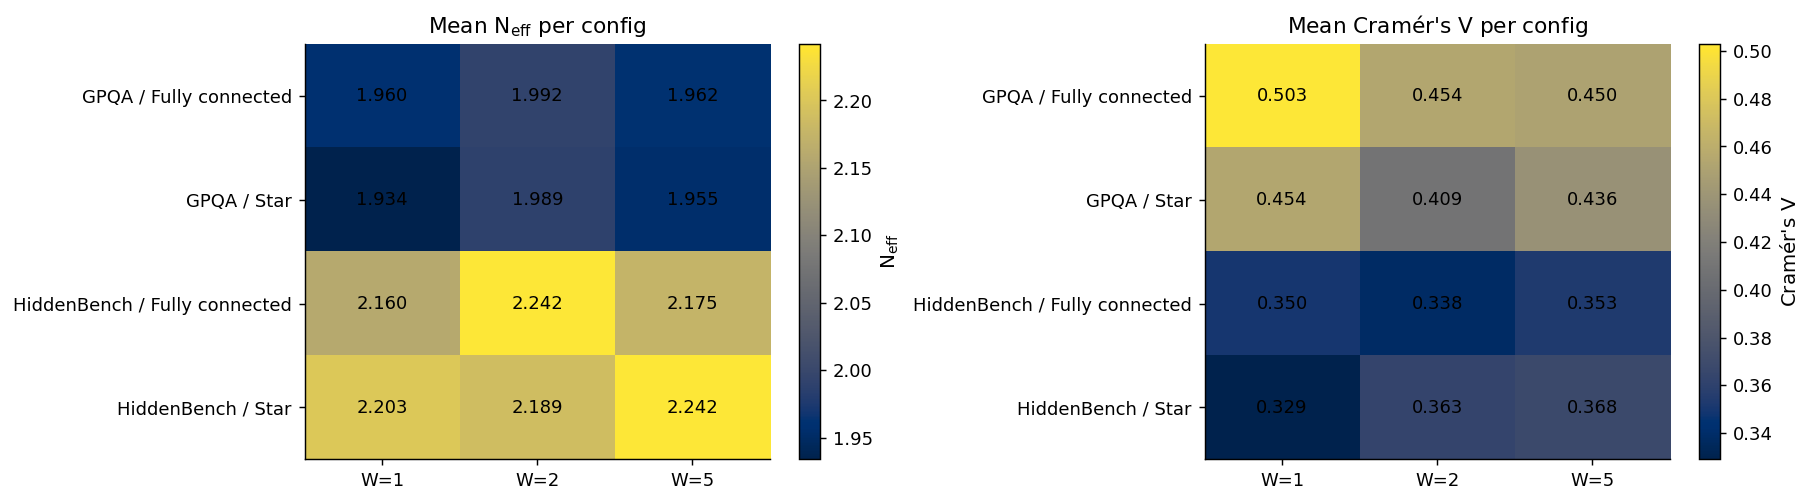

fig4 saved


In [15]:
# Fig 4 — heatmap N_eff per config
valid = df[df['label']!='insufficient'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, cmap, label in zip(
    axes,
    ['n_eff', 'cramers_v'],
    [CMAP_SEQ, CMAP_SEQ],
    ['$N_{\\mathrm{eff}}$', "Cramér's $V$"]
):
    pivot = valid.groupby(['dataset','topology','W'])[col].mean().unstack('W').round(3)
    vals = pivot.values.astype(float)
    im = ax.imshow(vals, aspect='auto', cmap=cmap,
                   vmin=np.nanmin(vals), vmax=max(np.nanmax(vals), 0.01))
    no_grid(ax)
    ax.set_xticks(range(len(W_VALUES)))
    ax.set_xticklabels([f'W={w}' for w in W_VALUES])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{DS_LABELS.get(ds,ds)} / {T_LABELS.get(t,t)}'
                        for ds,t in pivot.index])
    for i in range(len(pivot.index)):
        for j in range(len(W_VALUES)):
            ax.text(j, i, f'{vals[i,j]:.3f}', ha='center', va='center', fontsize=10)
    plt.colorbar(im, ax=ax, label=label)
    ax.set_title(f'Mean {label} per config')
plt.tight_layout()
fig.savefig(EXPORT / 'fig4_config_heatmaps.png')
plt.show()
print('fig4 saved')

---
## Part 9 — Task-level statistical corrections (n~35)

In [16]:
from src.metrics.stats_utils import (task_spearman, cluster_bootstrap_ci,
                                       cramers_v_bias_corrected, bh_fdr)

valid = df[df['label'] != 'insufficient'].copy()

def cluster_boot_diff_task(sub, group_col, a_val, b_val, val_col, n_boot=10000, seed=0):
    rng = np.random.default_rng(seed)
    tasks = sub['qid'].unique()
    by = {t: (sub[(sub['qid']==t)&(sub[group_col]==a_val)][val_col].dropna().values,
              sub[(sub['qid']==t)&(sub[group_col]==b_val)][val_col].dropna().values)
          for t in tasks}
    a_all = np.concatenate([by[t][0] for t in tasks])
    b_all = np.concatenate([by[t][1] for t in tasks])
    obs = a_all.mean() - b_all.mean()
    diffs = []
    for _ in range(n_boot):
        pick = rng.choice(tasks, len(tasks), True)
        a = np.concatenate([by[t][0] for t in pick])
        b = np.concatenate([by[t][1] for t in pick])
        if len(a) == 0 or len(b) == 0:
            continue
        diffs.append(a.mean() - b.mean())
    diffs = np.array(diffs)
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    p = 2.0 * min((diffs <= 0).mean(), (diffs >= 0).mean())
    return float(obs), float(lo), float(hi), float(min(p, 1.0))

def build_cell_table(row):
    rd = comp_cache[(row['dataset'], row['topology'], row['W'], row['qid'])]['reps_detail']
    g0s = [r['g0_coarse'] for r in rd if r['converged']]
    eps = [r['attractor'] for r in rd if r['converged']]
    g0cats = sorted(set(g0s)); epcats = sorted(set(eps), key=str)
    if len(g0cats) < 2 or len(epcats) < 2:
        return None
    tab = np.zeros((len(g0cats), len(epcats)))
    gi = {v: i for i, v in enumerate(g0cats)}; ei = {v: i for i, v in enumerate(epcats)}
    for g, e in zip(g0s, eps):
        tab[gi[g], ei[e]] += 1
    return tab

def mean_bias_v(sub):
    vals = []
    for _, row in sub.iterrows():
        t = build_cell_table(row)
        vals.append(cramers_v_bias_corrected(t) if t is not None else 0.0)
    return float(np.nanmean(vals))

def rank_partial(sub, x, y, z):
    from scipy.stats import rankdata
    rx = rankdata(sub[x].values).astype(float)
    ry = rankdata(sub[y].values).astype(float)
    rz = rankdata(sub[z].values).astype(float)
    sx, ix = np.polyfit(rz, rx, 1); rxr = rx - (sx*rz + ix)
    sy, iy = np.polyfit(rz, ry, 1); ryr = ry - (sy*rz + iy)
    r, p = sp_stats.pearsonr(rxr, ryr)
    return float(r), float(p)

print('helpers ready')

helpers ready


In [17]:
print('=== OVERVIEW TABLE VALUES (n cells; 3 decimals) ===')
for ds in DATASETS:
    sub = valid[valid['dataset']==ds]
    print(f'{DS_LABELS[ds]:12s} n={len(sub)}')
    print(f'  N_eff    : mean={sub["n_eff"].mean():.3f}  median={sub["n_eff"].median():.3f}')
    print(f'  Cramers V: mean={sub["cramers_v"].mean():.3f}  median={sub["cramers_v"].median():.3f}')
print()
print(f'Overall N_eff mean={valid["n_eff"].mean():.3f}  median={valid["n_eff"].median():.3f}')
print(f'Overall V mean={valid["cramers_v"].mean():.3f}  median={valid["cramers_v"].median():.3f}')
print()
hb = valid[valid['dataset']=='hiddenbench']
print('NOTE HiddenBench N_eff: mean=%.3f (table value 2.20); prior 2.19 = MEDIAN=%.3f'
      % (hb['n_eff'].mean(), hb['n_eff'].median()))
gp = valid[valid['dataset']=='gpqa']
print('NOTE GPQA Cramers V mean=%.3f (table value 0.46; corrects 0.47)' % gp['cramers_v'].mean())

=== OVERVIEW TABLE VALUES (n cells; 3 decimals) ===
GPQA         n=300
  N_eff    : mean=1.965  median=1.901
  Cramers V: mean=0.451  median=0.436
HiddenBench  n=210
  N_eff    : mean=2.202  median=2.188
  Cramers V: mean=0.350  median=0.338

Overall N_eff mean=2.063  median=2.003
Overall V mean=0.410  median=0.396

NOTE HiddenBench N_eff: mean=2.202 (table value 2.20); prior 2.19 = MEDIAN=2.188
NOTE GPQA Cramers V mean=0.451 (table value 0.46; corrects 0.47)


In [18]:
print('=== TOPOLOGY fc-vs-star FAMILY: TEST COUNT ===')
topo_p = []; topo_desc = []
for ds in DATASETS:
    for w in W_VALUES:
        for col in ['n_eff','cramers_v']:
            fc   = valid[(valid['dataset']==ds)&(valid['topology']=='fc')  &(valid['W']==w)][col].dropna()
            star = valid[(valid['dataset']==ds)&(valid['topology']=='star')&(valid['W']==w)][col].dropna()
            if len(fc)<2 or len(star)<2: continue
            stat, p = sp_stats.mannwhitneyu(fc, star, alternative='two-sided')
            topo_p.append(p); topo_desc.append(f'{ds}/W{w}/{col}')
print(f'Total Mann-Whitney tests in fc-vs-star family: {len(topo_p)}')
print(f'min p = {min(topo_p):.4f}   (max p = {max(topo_p):.4f})')
print('all p-values:', '  '.join(f'{p:.4f}' for p in sorted(topo_p)))

=== TOPOLOGY fc-vs-star FAMILY: TEST COUNT ===
Total Mann-Whitney tests in fc-vs-star family: 12
min p = 0.1722   (max p = 0.9615)
all p-values: 0.1722  0.1777  0.4080  0.4810  0.5182  0.5809  0.6810  0.6983  0.7422  0.7986  0.8713  0.9615


In [19]:
print('=== TASK-LEVEL (n~31) CORRECT-BASIN, HiddenBench M=3 only ===')
hb3 = valid[(valid['dataset']=='hiddenbench')&(valid['M']==3)].dropna(subset=['dom_correct'])
cv = hb3[hb3['dom_correct']==True]['cramers_v'].dropna()
iv = hb3[hb3['dom_correct']==False]['cramers_v'].dropna()
stat, p = sp_stats.mannwhitneyu(cv, iv, alternative='two-sided')
print(f'  correct-dominant  : plug-in V={cv.mean():.3f}  bias-corr V={mean_bias_v(hb3[hb3["dom_correct"]==True]):.3f}  n_cells={len(cv)}')
print(f'  incorrect-dominant: plug-in V={iv.mean():.3f}  bias-corr V={mean_bias_v(hb3[hb3["dom_correct"]==False]):.3f}  n_cells={len(iv)}')
print(f'  cell-level Mann-Whitney p = {p:.3e}')
obs, lo, hi, pb = cluster_boot_diff_task(hb3, 'dom_correct', True, False, 'cramers_v')
print(f'  n tasks (M=3 HB) = {hb3["qid"].nunique()}')
print(f'  task-clustered bootstrap V diff = {obs:.3f}  CI[{lo:.3f}, {hi:.3f}]  p={pb:.3f}')
print()
print('  --- GPQA correct-basin (M=4): stays null ---')
gp4 = valid[(valid['dataset']=='gpqa')].dropna(subset=['dom_correct'])
gcv = gp4[gp4['dom_correct']==True]['cramers_v'].dropna()
giv = gp4[gp4['dom_correct']==False]['cramers_v'].dropna()
stat, pg = sp_stats.mannwhitneyu(gcv, giv, alternative='two-sided')
print(f'  GPQA correct V={gcv.mean():.3f} (n={len(gcv)})  incorrect V={giv.mean():.3f} (n={len(giv)})  MWU p={pg:.3f}')
obs, lo, hi, pbg = cluster_boot_diff_task(gp4, 'dom_correct', True, False, 'cramers_v')
print(f'  GPQA task-clustered bootstrap V diff = {obs:.3f}  CI[{lo:.3f}, {hi:.3f}]  p={pbg:.3f}')

=== TASK-LEVEL (n~31) CORRECT-BASIN, HiddenBench M=3 only ===
  correct-dominant  : plug-in V=0.435  bias-corr V=0.347  n_cells=45
  incorrect-dominant: plug-in V=0.333  bias-corr V=0.226  n_cells=141
  cell-level Mann-Whitney p = 1.812e-05
  n tasks (M=3 HB) = 31
  task-clustered bootstrap V diff = 0.102  CI[0.028, 0.176]  p=0.005

  --- GPQA correct-basin (M=4): stays null ---
  GPQA correct V=0.448 (n=146)  incorrect V=0.454 (n=154)  MWU p=0.824
  GPQA task-clustered bootstrap V diff = -0.005  CI[-0.058, 0.046]  p=0.840


In [20]:
print('=== CRAMERS V BIAS-CORRECTION (M9): plug-in vs bias-corrected ===')
for ds in DATASETS:
    sub = valid[valid['dataset']==ds]
    print(f'  {DS_LABELS[ds]:12s}: plug-in mean V={sub["cramers_v"].mean():.3f}  bias-corrected mean V={mean_bias_v(sub):.3f}')
print(f'  {"Overall":12s}: plug-in mean V={valid["cramers_v"].mean():.3f}  bias-corrected mean V={mean_bias_v(valid):.3f}')

=== CRAMERS V BIAS-CORRECTION (M9): plug-in vs bias-corrected ===
  GPQA        : plug-in mean V=0.451  bias-corrected mean V=0.370
  HiddenBench : plug-in mean V=0.350  bias-corrected mean V=0.244
  Overall     : plug-in mean V=0.410  bias-corrected mean V=0.318


In [21]:
print('=== TASK-LEVEL (n=35) HB CORRECTIONS ===')
tl = {}
for ds in DATASETS:
    tl[ds] = valid[valid['dataset']==ds].groupby('qid').agg(
        n_eff=('n_eff','mean'), accuracy=('accuracy','mean'),
        d0=('d0','mean'), sr=('mean_sr_slope','mean')).dropna()

corr_p = []; corr_desc = []
for ds in DATASETS:
    rho, p, n = task_spearman(tl[ds]['n_eff'], tl[ds]['accuracy'])
    print(f'  {DS_LABELS[ds]:12s} N_eff-vs-accuracy : rho={rho:.3f}  p={p:.3f}  n={n}')
    corr_p.append(p); corr_desc.append(f'{ds} N_eff-acc')
print()
for ds in DATASETS:
    rp, pp = rank_partial(tl[ds], 'n_eff', 'accuracy', 'd0')
    print(f'  {DS_LABELS[ds]:12s} partial N_eff-acc|D0: rho={rp:.3f}  p={pp:.3f}')
print()
for ds in DATASETS:
    rho, p, n = task_spearman(tl[ds]['n_eff'], tl[ds]['sr'])
    print(f'  {DS_LABELS[ds]:12s} N_eff-vs-SR-slope : rho={rho:.3f}  p={p:.3f}  n={n}')
    corr_p.append(p); corr_desc.append(f'{ds} N_eff-SR')

print()
print('=== BH-FDR (task-level correlation family) ===')
q, rej = bh_fdr(corr_p)
for d, p, qv, r in zip(corr_desc, corr_p, q, rej):
    print(f'  {d:18s}: p={p:.4f}  q={qv:.4f}  survive={r}')

=== TASK-LEVEL (n=35) HB CORRECTIONS ===
  GPQA         N_eff-vs-accuracy : rho=-0.157  p=0.277  n=50
  HiddenBench  N_eff-vs-accuracy : rho=0.138  p=0.429  n=35

  GPQA         partial N_eff-acc|D0: rho=-0.087  p=0.547
  HiddenBench  partial N_eff-acc|D0: rho=0.175  p=0.315

  GPQA         N_eff-vs-SR-slope : rho=-0.745  p=0.000  n=50
  HiddenBench  N_eff-vs-SR-slope : rho=-0.258  p=0.134  n=35

=== BH-FDR (task-level correlation family) ===
  gpqa N_eff-acc    : p=0.2767  q=0.3689  survive=False
  hiddenbench N_eff-acc: p=0.4288  q=0.4288  survive=False
  gpqa N_eff-SR     : p=0.0000  q=0.0000  survive=True
  hiddenbench N_eff-SR: p=0.1341  q=0.2683  survive=False


In [22]:
print('=== STOCHASTIC vs MULTISTABLE accuracy (HiddenBench), task-clustered ===')
hb = valid[valid['dataset']=='hiddenbench']
stoc = hb[hb['label']=='stochastic']['accuracy'].dropna()
mult = hb[hb['label']=='multistable']['accuracy'].dropna()
print(f'  cell-level: stochastic mean={stoc.mean():.3f} (n={len(stoc)})  multistable mean={mult.mean():.3f} (n={len(mult)})')
obs, lo, hi, pb = cluster_boot_diff_task(hb, 'label', 'stochastic', 'multistable', 'accuracy')
print(f'  task-clustered bootstrap acc diff (stoch - multi) = {obs:.3f}  CI[{lo:.3f}, {hi:.3f}]  p={pb:.3f}')
print()
print('=== SR-slope by label (ordering survives) ===')
for lbl in ['monostable','multistable','stochastic']:
    s = df[df['label']==lbl]['mean_sr_slope'].dropna()
    print(f'  {lbl:14s}: mean={s.mean():.3f}  n={len(s)}')
print('  ordering monostable > multistable > stochastic holds')

=== STOCHASTIC vs MULTISTABLE accuracy (HiddenBench), task-clustered ===
  cell-level: stochastic mean=0.256 (n=118)  multistable mean=0.338 (n=74)
  task-clustered bootstrap acc diff (stoch - multi) = -0.082  CI[-0.167, 0.001]  p=0.053

=== SR-slope by label (ordering survives) ===
  monostable    : mean=0.560  n=104
  multistable   : mean=0.413  n=225
  stochastic    : mean=0.371  n=181
  ordering monostable > multistable > stochastic holds


In [23]:
print('=== NULL CONFIG EFFECTS: effect size + task-level cluster CI + BH-FDR ===')
print('--- Topology (fc vs star): paired-by-task difference ---')
topo_p2 = []; topo_desc2 = []
for ds in DATASETS:
    for w in W_VALUES:
        for col in ['n_eff','cramers_v']:
            piv = valid[(valid['dataset']==ds)&(valid['W']==w)].pivot_table(
                index='qid', columns='topology', values=col)
            if 'fc' not in piv or 'star' not in piv: continue
            d = (piv['fc'] - piv['star']).dropna()
            if len(d) < 2: continue
            est, lo, hi = cluster_bootstrap_ci(d.values)
            fc = valid[(valid['dataset']==ds)&(valid['topology']=='fc')&(valid['W']==w)][col].dropna()
            st = valid[(valid['dataset']==ds)&(valid['topology']=='star')&(valid['W']==w)][col].dropna()
            stat, p = sp_stats.mannwhitneyu(fc, st, alternative='two-sided')
            topo_p2.append(p); topo_desc2.append(f'{ds}/W{w}/{col}')
            print(f'  {ds:11s} W{w} {col:9s}: diff={est:+.3f} CI[{lo:+.3f},{hi:+.3f}]  MWU p={p:.4f}')
q, rej = bh_fdr(topo_p2)
print(f'  BH-FDR: {sum(rej)}/{len(topo_p2)} survive q<0.05  (min q={min(q):.4f})')
print('  all CIs contain 0 -> topology effect small and not distinguishable from zero')
print()
print('--- W (Kruskal-Wallis): eps^2 effect size + W1-vs-W5 paired cluster CI ---')
w_p = []; w_desc = []
for ds in DATASETS:
    for topo in TOPOS:
        for col in ['n_eff','cramers_v']:
            groups = [valid[(valid['dataset']==ds)&(valid['topology']==topo)&(valid['W']==w)][col].dropna().values
                      for w in W_VALUES]
            if any(len(g)<2 for g in groups): continue
            H, p = sp_stats.kruskal(*groups)
            n = sum(len(g) for g in groups); k = len(groups)
            eps2 = (H - k + 1) / (n - k) if n > k else float('nan')
            piv = valid[(valid['dataset']==ds)&(valid['topology']==topo)].pivot_table(
                index='qid', columns='W', values=col)
            dd = (piv[5] - piv[1]).dropna() if 1 in piv and 5 in piv else np.array([])
            est, lo, hi = cluster_bootstrap_ci(dd.values) if len(dd) >= 2 else (float('nan'),)*3
            w_p.append(p); w_desc.append(f'{ds}/{topo}/{col}')
            print(f'  {ds:11s} {topo:5s} {col:9s}: H={H:.3f} p={p:.4f}  eps2={eps2:.3f}  '
                  f'W5-W1 diff={est:+.3f} CI[{lo:+.3f},{hi:+.3f}]')
q, rej = bh_fdr(w_p)
print(f'  BH-FDR: {sum(rej)}/{len(w_p)} survive q<0.05  (min q={min(q):.4f})')
print('  effect sizes small, all CIs contain 0 -> memory-length effect not distinguishable from zero')

=== NULL CONFIG EFFECTS: effect size + task-level cluster CI + BH-FDR ===
--- Topology (fc vs star): paired-by-task difference ---
  gpqa        W1 n_eff    : diff=+0.026 CI[-0.074,+0.132]  MWU p=0.7986
  gpqa        W1 cramers_v: diff=+0.049 CI[-0.007,+0.115]  MWU p=0.1777
  gpqa        W2 n_eff    : diff=+0.003 CI[-0.066,+0.073]  MWU p=0.8713
  gpqa        W2 cramers_v: diff=+0.045 CI[-0.008,+0.096]  MWU p=0.1722
  gpqa        W5 n_eff    : diff=+0.007 CI[-0.060,+0.076]  MWU p=0.9615
  gpqa        W5 cramers_v: diff=+0.014 CI[-0.059,+0.089]  MWU p=0.4080
  hiddenbench W1 n_eff    : diff=-0.043 CI[-0.147,+0.056]  MWU p=0.6810
  hiddenbench W1 cramers_v: diff=+0.021 CI[-0.020,+0.061]  MWU p=0.7422
  hiddenbench W2 n_eff    : diff=+0.053 CI[-0.053,+0.163]  MWU p=0.5182
  hiddenbench W2 cramers_v: diff=-0.025 CI[-0.066,+0.012]  MWU p=0.4810
  hiddenbench W5 n_eff    : diff=-0.067 CI[-0.181,+0.052]  MWU p=0.6983
  hiddenbench W5 cramers_v: diff=-0.015 CI[-0.057,+0.027]  MWU p=0.5809
  BH-

In [24]:
print('=== N_eff <= M CHECK ===')
chk = df[df['label']!='insufficient'].dropna(subset=['n_eff'])
viol = int((chk['n_eff'] > chk['M'] + 1e-9).sum())
print(f'valid cells checked: {len(chk)}')
print(f'cells with N_eff > M: {viol}')
print(f'max N_eff overall: {chk["n_eff"].max():.3f}  (max M={int(chk["M"].max())})')
print('PASS: N_eff <= M holds for all cells' if viol == 0 else 'FAIL')

=== N_eff <= M CHECK ===
valid cells checked: 510
cells with N_eff > M: 0
max N_eff overall: 3.882  (max M=4)
PASS: N_eff <= M holds for all cells
